Task 4

In [1]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pandas.plotting import scatter_matrix
from pandas.plotting import parallel_coordinates
sns.set(style="whitegrid")

In [3]:
# Load dataset
df = pd.read_csv("clean_dataset.csv")
df.head()

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,1,30.83,0.000,1,1,Industrials,White,1.25,1,1,1,0,ByBirth,202,0,1
1,0,58.67,4.460,1,1,Materials,Black,3.04,1,1,6,0,ByBirth,43,560,1
2,0,24.50,0.500,1,1,Materials,Black,1.50,1,0,0,0,ByBirth,280,824,1
3,1,27.83,1.540,1,1,Industrials,White,3.75,1,1,5,1,ByBirth,100,3,1
4,1,20.17,5.625,1,1,Industrials,White,1.71,1,0,0,0,ByOtherMeans,120,0,1


In [4]:
df.tail()

,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
685,1,21.08,10.085,0,0,Education,Black,1.25,0,0,0,0,ByBirth,260,0,0
686,0,22.67,0.750,1,1,Energy,White,2.00,0,1,2,1,ByBirth,200,394,0
687,0,25.25,13.500,0,0,Healthcare,Latino,2.00,0,1,1,1,ByBirth,200,1,0
688,1,17.92,0.205,1,1,ConsumerStaples,White,0.04,0,0,0,0,ByBirth,280,750,0
689,1,35.00,3.375,1,1,Energy,Black,8.29,0,0,0,1,ByBirth,0,0,0


In [3]:
#Identify Categorical & Continuous Columns
print("Categorical Columns:")
print(df.select_dtypes(include=['object']).columns)

print("Continuous Columns:")
print(df.select_dtypes(include=['int64','float64']).columns)


Categorical Columns:
Index(['Industry', 'Ethnicity', 'Citizen'], dtype='object')
Continuous Columns:
Index(['Gender', 'Age', 'Debt', 'Married', 'BankCustomer', 'YearsEmployed',
       'PriorDefault', 'Employed', 'CreditScore', 'DriversLicense', 'ZipCode',
       'Income', 'Approved'],
      dtype='object')


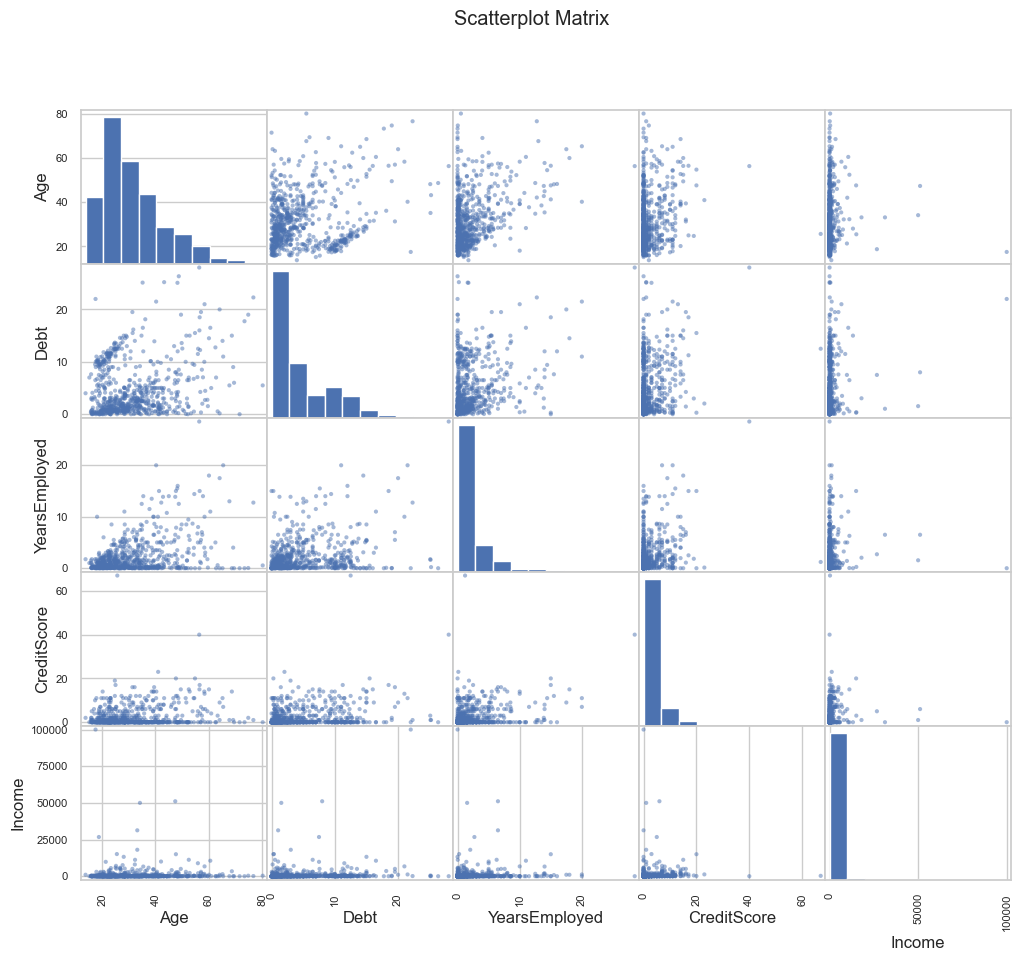

In [4]:
#1.SCATTERPLOT MATRIX (Multiple Continuous Variables)
cols = ['Age', 'Debt', 'YearsEmployed', 'CreditScore', 'Income']

scatter_matrix(df[cols], figsize=(12,10))
plt.suptitle("Scatterplot Matrix")
plt.show()


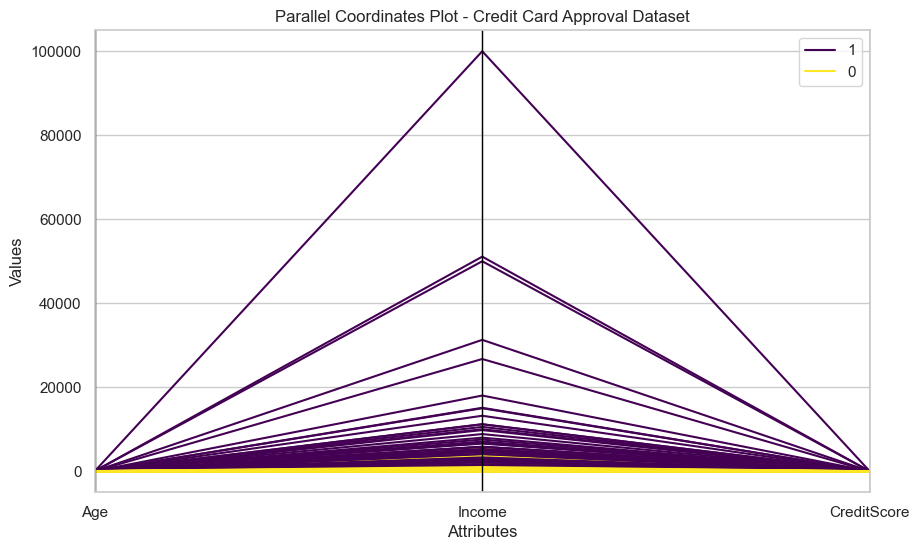

In [19]:
#2.PARALLEL COORDINATES PLOT

# Ensure Approved is categorical
df['Approved'] = df['Approved'].astype(str)

# Select required columns
pc_df = df[['Age', 'Income', 'CreditScore', 'Approved']]

plt.figure(figsize=(10,6))

parallel_coordinates(
    pc_df,
    class_column='Approved',
    colormap='viridis'
)
plt.title("Parallel Coordinates Plot - Credit Card Approval Dataset")
plt.xlabel("Attributes")
plt.ylabel("Values")
plt.grid(True)
plt.show()


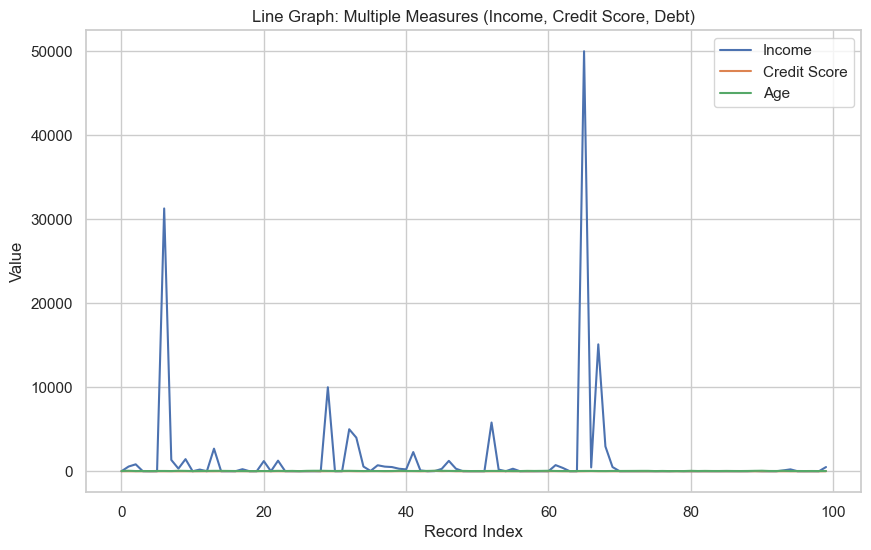

In [39]:
#3.LINE GRAPH (Multiple Measures)
plt.figure(figsize=(10, 6))

plt.plot(df['Income'].head(100), label='Income')
plt.plot(df['CreditScore'].head(100), label='Credit Score')
plt.plot(df['Age'].head(100), label='Age')

plt.xlabel("Record Index")
plt.ylabel("Value")
plt.title("Line Graph: Multiple Measures (Income, Credit Score, Debt)")
plt.legend()
plt.grid(True)
plt.show()


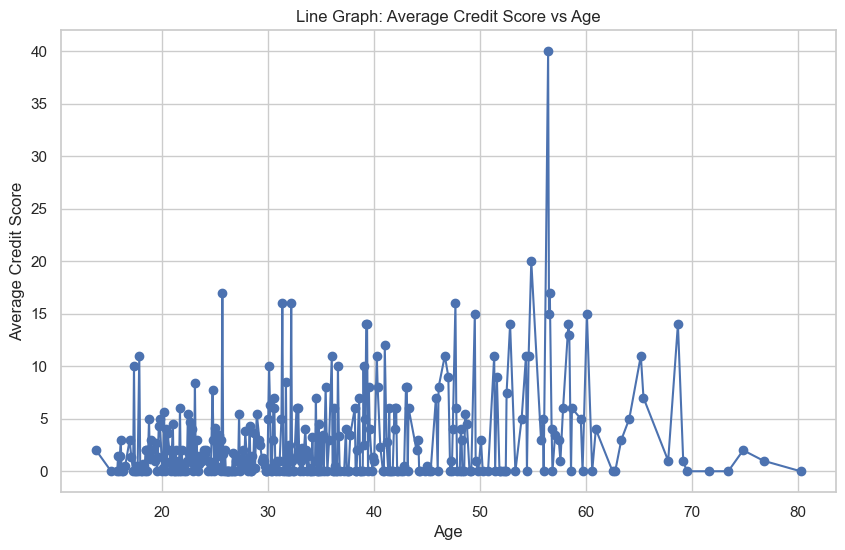

In [40]:
#3.LINE GRAPH (Average Credit Score vs Age)
# Group data: Average Credit Score for each Age
line_data = df.groupby('Age')['CreditScore'].mean().reset_index()

# Plot Line Graph
plt.figure(figsize=(10, 6))
plt.plot(
    line_data['Age'],
    line_data['CreditScore'],
    marker='o'
)

plt.xlabel("Age")
plt.ylabel("Average Credit Score")
plt.title("Line Graph: Average Credit Score vs Age")
plt.grid(True)
plt.show()


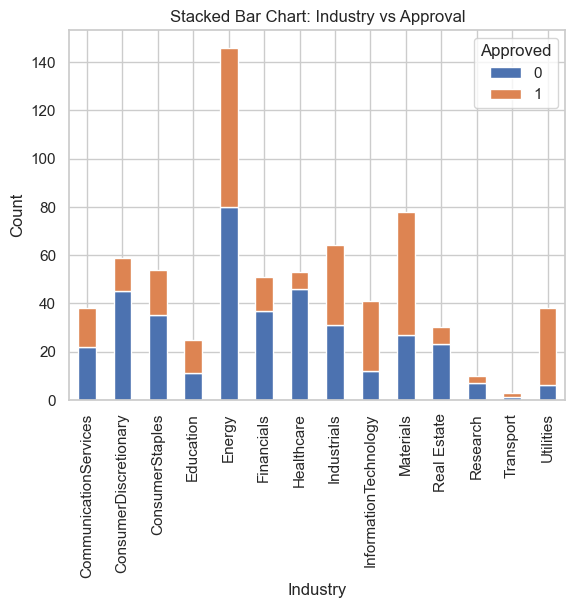

In [36]:
#4.STACKED BAR CHART (Multivariate)
ct = pd.crosstab(df['Industry'], df['Approved'])

ct.plot(kind='bar', stacked=True)
plt.title("Stacked Bar Chart: Industry vs Approval")
plt.xlabel("Industry")
plt.ylabel("Count")
plt.show()
